# Limpieza de datos

In [2]:
import pandas as pd

### Carga de archivo

In [3]:
fichero = 'C:/Users/evgen/Downloads/Barcelona Activa/Simulación Empresarial Proyecto/Equipo 27/ProjecteData/Equip_27/Data/df_original_260420.csv'
df = pd.read_csv(fichero)

In [4]:
print(df.shape)
df.head(5)

(10642, 18)


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [5]:
df.set_index('id', inplace=True)

In [6]:
variables = pd.DataFrame(columns=['Variable', 'Número de valores unicos', 'Tipo','Valores'])
for i, var in enumerate(df.columns):
    variables.loc[i] = [var, df[var].nunique(), df[var].dtype,df[var].unique().tolist()]

variables

,Variable,Número de valores unicos,Tipo,Valores
0,age,76,float64,"[59.0, 56.0, 41.0, 55.0, 54.0, 42.0, 60.0, 37...."
1,job,12,object,"[admin., technician, services, management, ret..."
2,marital,3,object,"[married, single, divorced, nan]"
3,education,4,object,"[secondary, tertiary, primary, unknown, nan]"
4,default,2,object,"[no, yes]"
5,balance,3703,int64,"[2343, 45, 1270, 2476, 184, 0, 830, 545, 1, 50..."
6,housing,2,object,"[yes, no]"
7,loan,2,object,"[no, yes]"
8,contact,3,object,"[unknown, cellular, telephone]"
9,day,31,int64,"[5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 19, 20, 21..."


### Revisión de valores nulos

In [7]:
# Valores nulos por variable
nulos = df.isnull().sum()

# Calcular el porcentaje de nulos
nulos_porcentaje = (nulos / len(df)) * 100

null_info = pd.DataFrame({
    'Variable': nulos.index,
    'Nulos': nulos.values,
    'Porcentaje de Nulos': nulos_porcentaje.values
})

null_info

,Variable,Nulos,Porcentaje de Nulos
0,age,9,0.084571
1,job,0,0.000000
2,marital,5,0.046984
3,education,7,0.065777
4,default,0,0.000000
5,balance,0,0.000000
6,housing,0,0.000000
7,loan,0,0.000000
8,contact,0,0.000000
9,day,0,0.000000


In [8]:
df_nulos = df[df.isna().any(axis=1)]
print(df_nulos.shape)
df_nulos

(21, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
id,,,,,,,,,,,,,,,,,
1089,53.0,management,NaN,secondary,no,1004,no,yes,telephone,22,dec,119,1,-1,0,unknown,yes
1182,NaN,management,married,tertiary,no,309,yes,no,cellular,5,feb,676,1,-1,0,unknown,yes
1301,37.0,technician,married,NaN,no,549,no,no,cellular,2,mar,239,1,-1,0,unknown,yes
1411,NaN,blue-collar,married,primary,no,4979,no,no,telephone,6,apr,180,1,-1,0,unknown,yes
2944,24.0,student,single,NaN,no,382,no,no,cellular,13,nov,256,2,92,3,failure,yes
3720,68.0,retired,NaN,secondary,no,4189,no,no,telephone,14,jul,897,2,-1,0,unknown,yes
4020,NaN,services,single,secondary,no,1934,no,no,cellular,29,sep,271,1,-1,0,unknown,yes
4738,37.0,management,single,NaN,no,102,yes,no,cellular,6,may,445,1,258,2,failure,yes
4855,34.0,management,NaN,tertiary,no,5,no,no,cellular,18,aug,370,2,-1,0,unknown,yes


### Variable **job**

In [9]:
df['job'].value_counts()

job
management       2447
blue-collar      1830
technician       1737
admin.           1279
services          881
retired           755
self-employed     388
student           354
unemployed        338
entrepreneur      308
housemaid         257
unknown            68
Name: count, dtype: int64

##### Cambia el tipo por string

In [10]:
df['job'] = df['job'].astype('string')

##### Reemplazamos **admin.** por **administration**

In [11]:
df['job'] = df['job'].replace('admin.', 'administration')

In [12]:
df['job'].value_counts()

job
management        2447
blue-collar       1830
technician        1737
administration    1279
services           881
retired            755
self-employed      388
student            354
unemployed         338
entrepreneur       308
housemaid          257
unknown             68
Name: count, dtype: Int64

### Variable **marital**

In [13]:
df['marital'].value_counts()

marital
married     6030
single      3374
divorced    1233
Name: count, dtype: int64

##### Cambia el tipo por string

In [14]:
df['marital'] = df['marital'].astype('string')

### Variable **education**

In [15]:
df['education'].value_counts()

education
secondary    5216
tertiary     3527
primary      1419
unknown       473
Name: count, dtype: int64

##### Cambia el tipo por string

In [16]:
df['education'] = df['education'].astype('string')

### Variable **default**

In [17]:
df['default'].value_counts()

default
no     10487
yes      155
Name: count, dtype: int64

##### Cambia el tipo por string

In [18]:
df['default'] = df['default'].astype('string')

### Variable **balance**

In [19]:
df['balance'].describe()

count    10642.000000
mean      1536.614828
std       3223.419300
min      -6847.000000
25%        127.000000
50%        558.000000
75%       1728.750000
max      81204.000000
Name: balance, dtype: float64

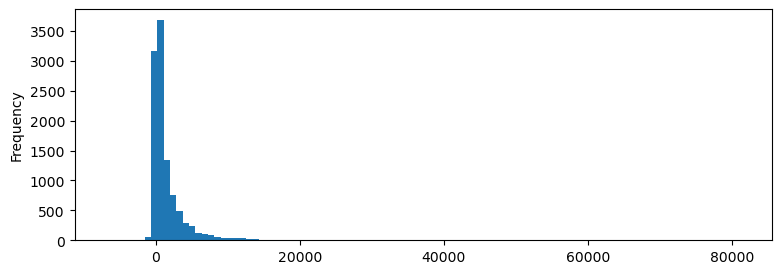

In [20]:
df['balance'].plot.hist(bins=100, figsize=(9,3));

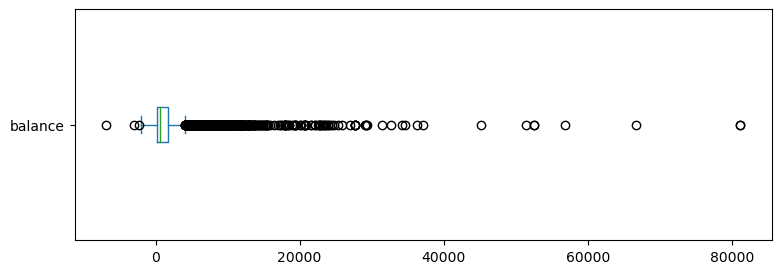

In [23]:
df['balance'].plot.box(figsize=(9,3), vert=False);

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10642 entries, 1 to 10642
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        10633 non-null  float64
 1   job        10642 non-null  string 
 2   marital    10637 non-null  string 
 3   education  10635 non-null  string 
 4   default    10642 non-null  string 
 5   balance    10642 non-null  int64  
 6   housing    10642 non-null  object 
 7   loan       10642 non-null  object 
 8   contact    10642 non-null  object 
 9   day        10642 non-null  int64  
 10  month      10642 non-null  object 
 11  duration   10642 non-null  int64  
 12  campaign   10642 non-null  int64  
 13  pdays      10642 non-null  int64  
 14  previous   10642 non-null  int64  
 15  poutcome   10642 non-null  object 
 16  deposit    10642 non-null  object 
dtypes: float64(1), int64(6), object(6), string(4)
memory usage: 1.5+ MB
